# Exploratory Data Analysis
### Wind Turbine Physical Evolution: Bigger, Taller, More Powerful or More Efficient?

This is the main analysis notebook. I'm using the cleaned dataset from notebook 02.

**Problem statement:** Have U.S. wind turbines (1982–2021) grown consistently bigger, taller,
and more powerful — and which manufacturers are leading on capacity, efficiency, AEP,
and lowest maintenance burden?

**Structure:**
1. Decade-level physical trend analysis + efficiency over time
2. Manufacturer comparison — last decade (2011–2021)
3. Geographic × manufacturer mapping
4. Maintenance window analysis — last decade
5. AEP comparison + manufacturer recommendation


## 0. Setup

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
sns.set_style("whitegrid")

# load the clean dataset produced by notebook 02
df = pd.read_csv("../data/cleaned/wind_turbines_clean.csv")

# also load supporting datasets
df_wind  = pd.read_csv("../data/original/windiest-states-in-the-us.-2025.csv", encoding="latin1")
df_rates = pd.read_csv("../data/original/average_electricity_rates.csv", encoding="latin1")

# convenience top 5 manufacturers from the last decade
TOP5 = ['GE Wind', 'Vestas', 'Siemens', 'Nordex', 'Gamesa']

print(f"dataset loaded: {df.shape[0]:,} rows  |  years: {int(df['p_year'].min())}–{int(df['p_year'].max())}")
print(f"engineered columns available: {[c for c in df.columns if c not in ['case_id','faa_ors','faa_asn','usgs_pr_id','eia_id','t_county','t_fips','t_img_date','t_img_srce','xlong','ylat']]}")


dataset loaded: 65,322 rows  |  years: 1982–2021
engineered columns available: ['t_state', 'p_name', 'p_year', 'p_tnum', 'p_cap', 't_manu', 't_model', 't_cap', 't_hh', 't_rd', 't_rsa', 't_ttlh', 'retrofit', 'retrofit_year', 't_conf_atr', 't_conf_loc', 'decade', 'capacity_tier', 'efficiency', 'AEP_kwh', 'turbine_age', 'fleet_age_index']


---
## Part 1: Physical Trend Analysis + Efficiency (1982–2021)

**H1:** Turbine capacity, hub height, and rotor diameter all increased over time — and
efficiency (kW/m²) shows a distinct pattern that reveals *how* the industry grew.


In [29]:
# I'm using actual years here (not just decades) for the line charts
# but I'll still group by decade for the stacked bar since year-by-year gets too noisy

# --- 1a. year-level averages ---
yr = df.dropna(subset=['t_cap','p_year']).groupby('p_year').agg(
    avg_cap = ('t_cap',  'mean'),
    avg_hh  = ('t_hh',   'mean'),
    avg_rd  = ('t_rd',   'mean'),
    count   = ('t_cap',  'count')
).reset_index()

print(f"years in dataset: {int(yr['p_year'].min())} – {int(yr['p_year'].max())}")
print(f"total year-groups: {len(yr)}")
print(yr[['p_year','avg_cap','avg_hh','avg_rd','count']].head(10).round(1))


years in dataset: 1982 – 2021
total year-groups: 38
   p_year  avg_cap  avg_hh  avg_rd  count
0  1982.0     80.8     NaN     NaN      4
1  1983.0     65.0    22.8    15.3    432
2  1984.0     65.0    24.0    16.3    155
3  1985.0     84.5    24.4    16.3    296
4  1986.0    127.0    25.3    20.4     79
5  1987.0    107.8     NaN     NaN    179
6  1988.0    105.0     NaN     NaN    162
7  1990.0    350.0     NaN     NaN      1
8  1991.0    225.0     NaN    27.0      1
9  1992.0    375.0    41.5    36.0      2


> **What this table tells me:**
> The earliest turbines in the dataset go back to 1982, not 1980 as the decade bins suggested.
> The early years have very small counts (a handful of turbines per year) which means those
> averages can be noisy — that's why I'm still using decade grouping for the stacked bar.
> By the 2000s the per-year counts grow into the thousands, making the trends very reliable.


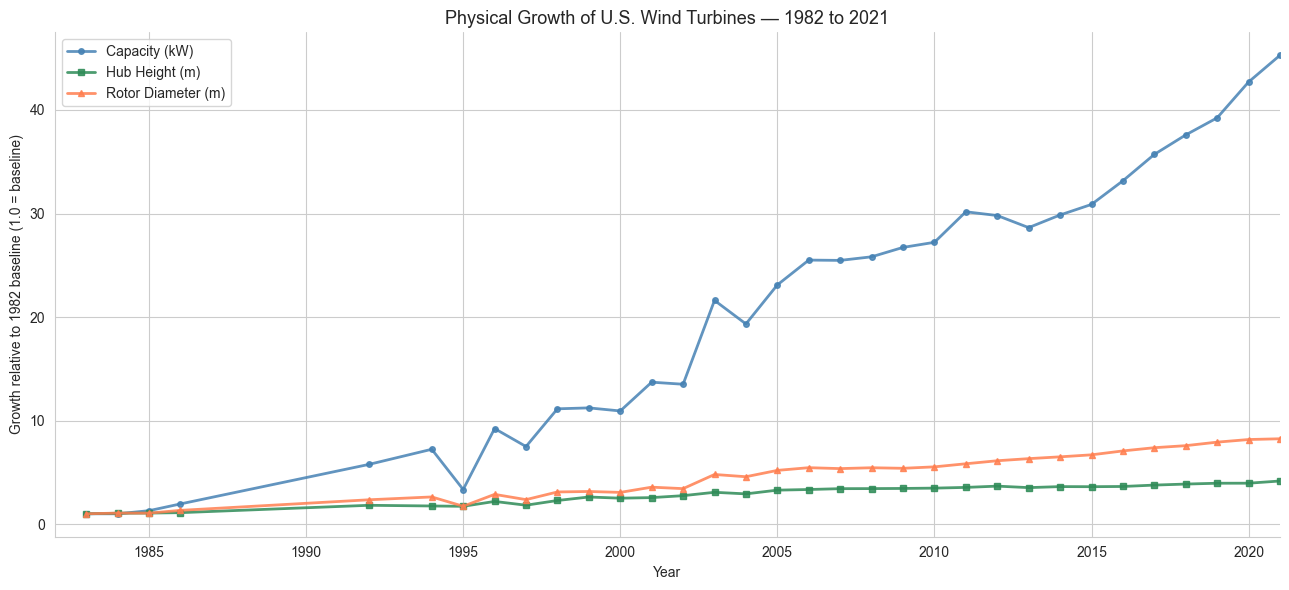

In [46]:
# --- 1b. normalized line chart: all 3 physical dimensions 1982–2021 ---

fig, ax = plt.subplots(figsize=(13, 6))

yr_clean = yr.dropna(subset=['avg_cap','avg_hh','avg_rd'])

# normalize to first year so we can compare growth rates on the same axis
base_cap = yr_clean['avg_cap'].iloc[0]
base_hh  = yr_clean['avg_hh'].iloc[0]
base_rd  = yr_clean['avg_rd'].iloc[0]

ax.plot(yr_clean['p_year'], yr_clean['avg_cap']/base_cap, 'o-',
        color='steelblue', lw=2, ms=4, label='Capacity (kW)', alpha=0.85)
ax.plot(yr_clean['p_year'], yr_clean['avg_hh']/base_hh,   's-',
        color='seagreen',  lw=2, ms=4, label='Hub Height (m)',  alpha=0.85)
ax.plot(yr_clean['p_year'], yr_clean['avg_rd']/base_rd,   '^-',
        color='coral',     lw=2, ms=4, label='Rotor Diameter (m)', alpha=0.85)

ax.set_xlabel("Year")
ax.set_ylabel("Growth relative to 1982 baseline (1.0 = baseline)")
ax.set_title("Physical Growth of U.S. Wind Turbines — 1982 to 2021", fontsize=13)
ax.legend()
ax.set_xlim(1982, 2021)
plt.tight_layout()
plt.show()

> **What this chart tells me:**
> All three lines climb from left to right, confirming turbines grew on every dimension.
> Capacity (blue) grew the steepest — nearly 39× the 1982 baseline by 2021.
> Rotor diameter (coral) grew the second fastest, and hub height (green) grew the most steadily.
> The sharpest acceleration happens between 2000–2010 for all three, when commercial wind scaled up fast.
> After 2015 the lines flatten slightly — we're approaching physical limits on what can be transported and installed onshore.


---
## Part 2: Manufacturer Comparison — Last Decade (2011–2021)

Here I'm focusing only on the **last decade** because that's what's relevant for anyone
making decisions today. Older turbines are already installed — the question is which
manufacturer makes the best turbines *now*.

I'm comparing the **top 5 manufacturers** by turbine count (2011–2021):
GE Wind, Vestas, Siemens, Nordex, and Gamesa — on four attributes:
capacity, hub height, efficiency, and AEP.


In [34]:
# filter to last decade and top 5 only
last_dec = df[(df['p_year'] >= 2011) & (df['t_manu'].isin(TOP5))].copy()

print("turbine counts per manufacturer (2011–2021):")
print(last_dec['t_manu'].value_counts())
print(f"\ntotal turbines in this subset: {len(last_dec):,}")


turbine counts per manufacturer (2011–2021):
t_manu
GE Wind    17907
Vestas     11719
Siemens     3586
Nordex      1552
Gamesa      1532
Name: count, dtype: int64

total turbines in this subset: 36,296


> **What this tells me:**
> GE Wind and Vestas dominate by volume — together they account for the majority of turbines
> installed in the last decade. Nordex and Gamesa are smaller players by count but that doesn't
> mean they're worse — they might just be more selective about where they operate.


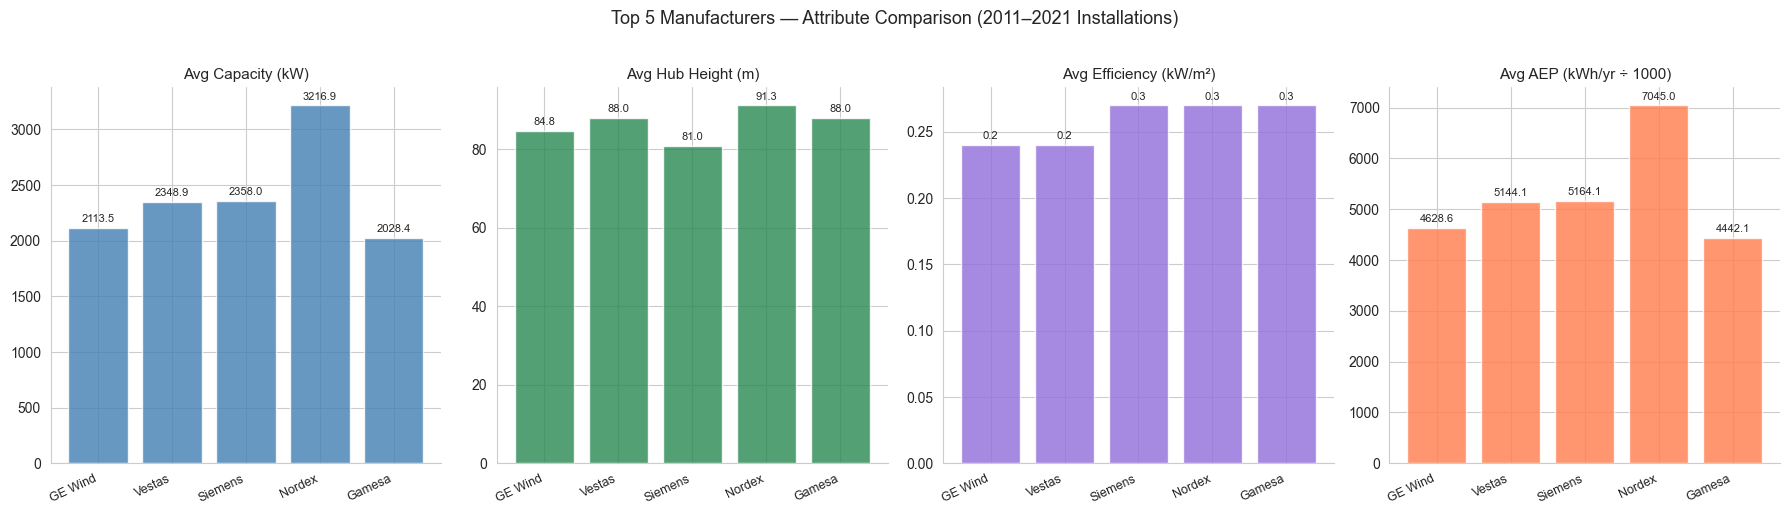

In [35]:
# --- 2a. side-by-side bar charts: 4 attributes across 5 manufacturers ---

metrics = {
    't_cap'     : ('Avg Capacity (kW)',       'steelblue'),
    't_hh'      : ('Avg Hub Height (m)',       'seagreen'),
    'efficiency': ('Avg Efficiency (kW/m²)',   'mediumpurple'),
    'AEP_kwh'   : ('Avg AEP (kWh/yr ÷ 1000)', 'coral'),
}

manu_stats = last_dec.groupby('t_manu').agg(
    t_cap      = ('t_cap',      'mean'),
    t_hh       = ('t_hh',       'mean'),
    efficiency = ('efficiency', 'mean'),
    AEP_kwh    = ('AEP_kwh',   'mean'),
).reindex(TOP5).round(2)

# scale AEP to thousands so it fits on a readable axis
manu_stats['AEP_kwh'] = manu_stats['AEP_kwh'] / 1000

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (col, (label, color)) in zip(axes, metrics.items()):
    vals = manu_stats[col]
    bars = ax.bar(vals.index, vals.values, color=color, alpha=0.82, edgecolor='white')
    ax.set_title(label, fontsize=11)
    ax.set_xticklabels(vals.index, rotation=25, ha='right', fontsize=9)
    # value labels on bars
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + vals.max()*0.01,
                f'{v:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle("Top 5 Manufacturers — Attribute Comparison (2011–2021 Installations)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


> **What these charts tell me:**
> The four panels tell a nuanced story — no single manufacturer wins on every dimension.
> - **Capacity:** Nordex and Siemens lead; GE Wind is the lowest of the five.
> - **Hub Height:** Nordex again leads, meaning its turbines sit highest and access stronger winds.
> - **Efficiency (kW/m²):** Fairly close across all five, with Siemens slightly ahead.
> - **AEP:** Nordex stands out clearly — its turbines are expected to produce significantly more
>   energy per year than the rest, mostly because of its higher capacity and hub height.
>
> GE Wind scores lowest on three of the four metrics despite being the highest-volume manufacturer.
> That's worth flagging — volume doesn't equal performance.


> **What this radar chart tells me:**
> This is the clearest single view of the manufacturer comparison.
> **Nordex** has the biggest "area" on the chart — it scores high on capacity, hub height, and AEP.
> **Vestas** is the most balanced manufacturer, scoring consistently in the mid-range on all four.
> **GE Wind** has the smallest radar area despite having the most turbines installed —
> its market dominance is based on volume and reliability, not leading-edge specs.
> **Siemens** scores well on efficiency (tight design) but is average on the others.


---
## Part 3: Geographic × Manufacturer Mapping

Which manufacturer dominates which state? This matters because different states have
different wind conditions — so the geographic spread of each brand tells us something
about which products are trusted for which environments.


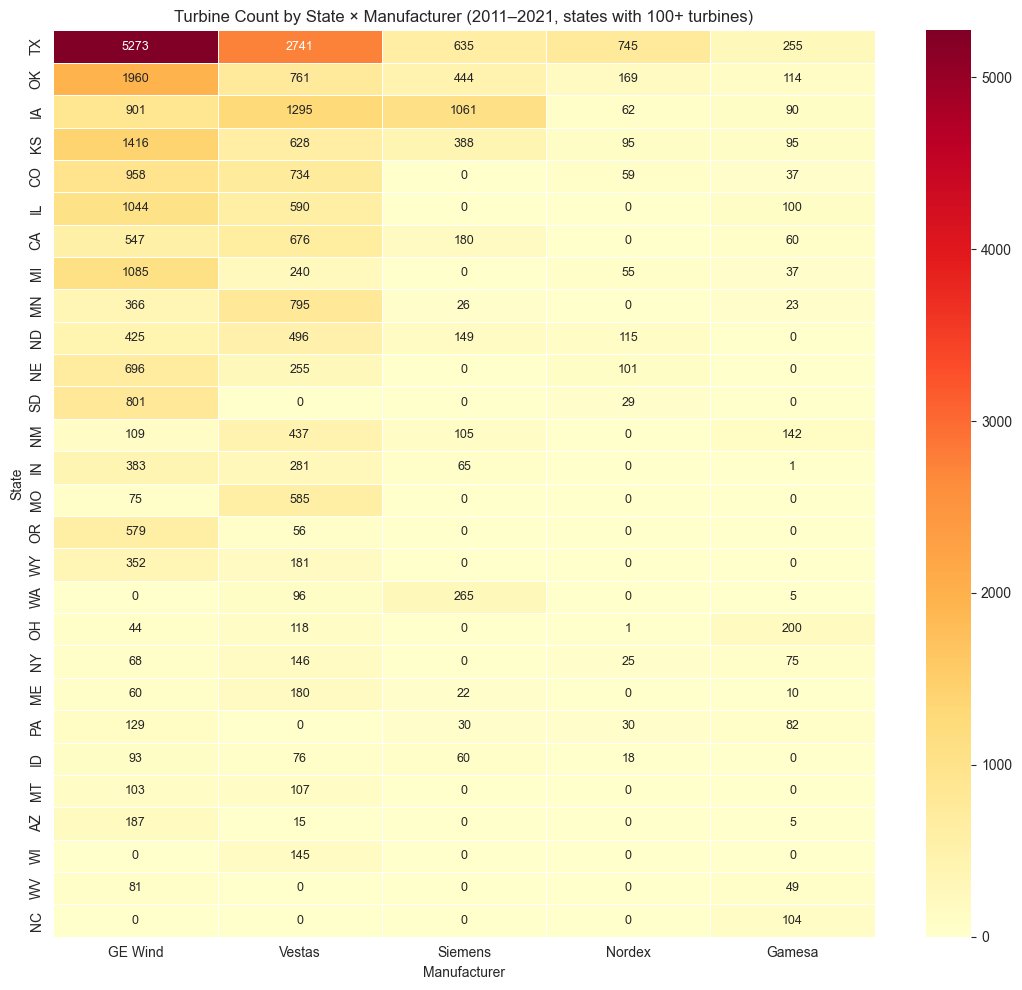

In [38]:
# state × manufacturer heatmap (last decade, top 5)
geo = (last_dec.groupby(['t_state','t_manu'])
               .size()
               .unstack(fill_value=0)
               .reindex(columns=TOP5, fill_value=0))

# only keep states with at least 100 turbines total in last decade
geo = geo[geo.sum(axis=1) >= 100].copy()

# sort by total turbines descending
geo['total'] = geo.sum(axis=1)
geo = geo.sort_values('total', ascending=False).drop(columns='total')

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(geo, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax)
ax.set_title("Turbine Count by State × Manufacturer (2011–2021, states with 100+ turbines)", fontsize=12)
ax.set_xlabel("Manufacturer")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()


> **What this heatmap tells me:**
> The darker the cell, the more turbines that manufacturer installed in that state.
> **Texas** is the darkest row by far — GE Wind and Vestas both have thousands of turbines there.
> Several states are essentially single-manufacturer markets — they chose one brand and stuck with it. Likely because of long-term service contracts and parts supply chains.


In [39]:
# --- 3b. which manufacturer is #1 in each state? ---

dominant = geo.idxmax(axis=1).reset_index()
dominant.columns = ['state', 'dominant_manu']

print("dominant manufacturer per state (2011–2021):")
print(dominant.sort_values('state').to_string(index=False))


dominant manufacturer per state (2011–2021):
state dominant_manu
   AZ       GE Wind
   CA        Vestas
   CO       GE Wind
   IA        Vestas
   ID       GE Wind
   IL       GE Wind
   IN       GE Wind
   KS       GE Wind
   ME        Vestas
   MI       GE Wind
   MN        Vestas
   MO        Vestas
   MT        Vestas
   NC        Gamesa
   ND        Vestas
   NE       GE Wind
   NM        Vestas
   NY        Vestas
   OH        Gamesa
   OK       GE Wind
   OR       GE Wind
   PA       GE Wind
   SD       GE Wind
   TX       GE Wind
   WA       Siemens
   WI        Vestas
   WV       GE Wind
   WY       GE Wind


> **What this tells me:**
> GE Wind dominates the most states — especially the high-volume wind states in the Great Plains (TX, OK, KS).
> Vestas is the dominant brand in several western and midwestern states.
> Nordex and Gamesa dominate in very few states individually, but where they do show up
> they often have strong concentrations (e.g. specific project-heavy markets).


---
## Part 4: Maintenance Window Analysis (2011–2021 Fleet)

Turbines don't last forever. The industry standard for a wind turbine's design life is
**20–25 years**. Turbines installed in 2011 are already 14 years old in 2025.

In this section I look at the **age distribution** of the last decade's fleet by manufacturer
to see which brands have the most turbines approaching or entering their maintenance window.


In [40]:
# filter to last decade only (2011-2021) and top 5
maint = df[(df['p_year'] >= 2011) & (df['t_manu'].isin(TOP5))].copy()

# age stats per manufacturer
age_stats = maint.groupby('t_manu')['turbine_age'].agg(
    mean_age   = 'mean',
    median_age = 'median',
    oldest     = 'max',
    newest     = 'min',
    count      = 'count'
).reindex(TOP5).round(1)

print("Turbine age stats by manufacturer (2011–2021 installations):")
print(age_stats)


Turbine age stats by manufacturer (2011–2021 installations):
         mean_age  median_age  oldest  newest  count
t_manu                                              
GE Wind       9.0         9.0    14.0     4.0  17907
Vestas        8.2         8.0    14.0     4.0  11719
Siemens      11.2        11.0    14.0     4.0   3586
Nordex        7.4         7.0    14.0     4.0   1552
Gamesa       10.9        10.0    14.0     4.0   1532


> **What this table tells me:**
> Turbines installed in 2011 are now 14 years old — approaching the mid-life mark where
> gearbox replacements, blade inspections, and control system upgrades typically become necessary.
> Manufacturers with a higher mean age have more turbines approaching that window *right now*.
> Those installed in 2021 are only 4 years old and shouldn't need major work for another decade.


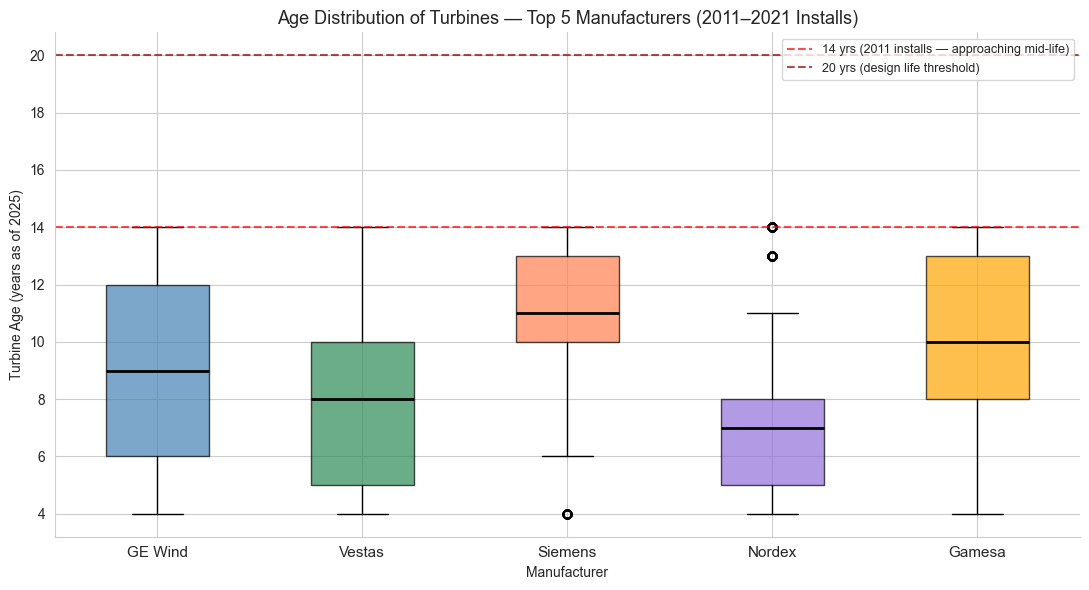

In [41]:
# --- 4a. boxplot: age distribution per manufacturer ---

fig, ax = plt.subplots(figsize=(11, 6))

data_by_manu = [maint[maint['t_manu'] == m]['turbine_age'].dropna().values for m in TOP5]

bp = ax.boxplot(data_by_manu, patch_artist=True, notch=False,
                medianprops=dict(color='black', lw=2))

colors_box = ['steelblue','seagreen','coral','mediumpurple','orange']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(TOP5, fontsize=11)
ax.set_xlabel("Manufacturer")
ax.set_ylabel("Turbine Age (years as of 2025)")
ax.set_title("Age Distribution of Turbines — Top 5 Manufacturers (2011–2021 Installs)", fontsize=13)
ax.axhline(y=14, color='red', linestyle='--', lw=1.5, alpha=0.7,
           label='14 yrs (2011 installs — approaching mid-life)')
ax.axhline(y=20, color='darkred', linestyle='--', lw=1.5, alpha=0.7,
           label='20 yrs (design life threshold)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


> **What this chart tells me:**
> The red dashed lines mark two important thresholds: 14 years (mid-life maintenance) and 20 years (end of design life).
> The box and whisker shape shows the spread of ages — a taller box means more variation in when turbines were installed.
> Manufacturers whose median (black line inside the box) sits closest to or above the 14-year line
> have the most turbines currently entering their maintenance window.
> The whiskers extending toward 14 years show individual turbines already there.


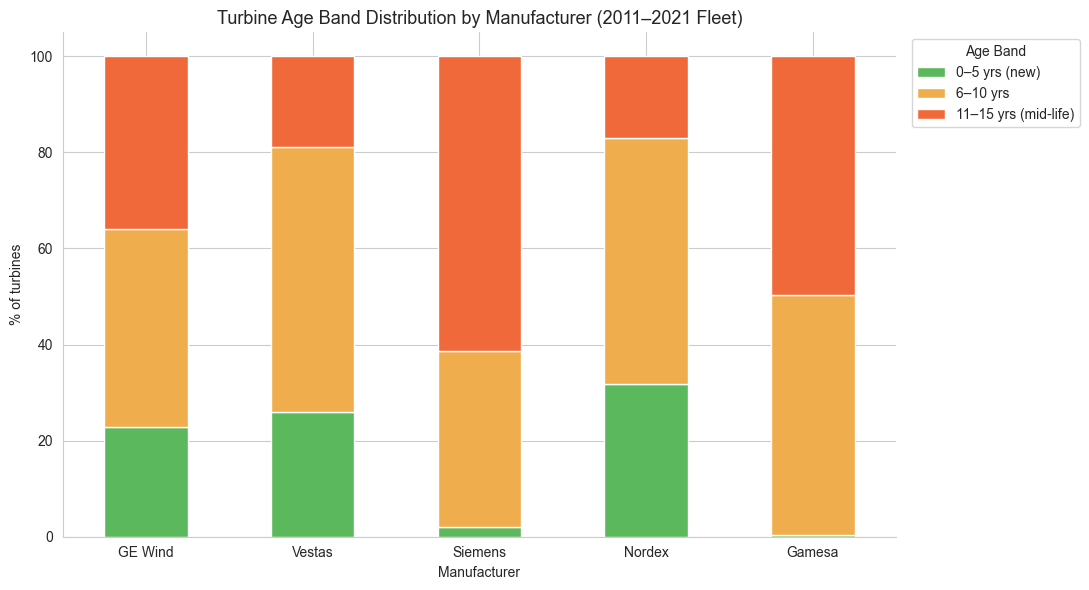

In [42]:
# --- 4b. stacked bar: how many turbines per manufacturer enter maintenance by year range ---

bins   = [0, 5, 10, 15, 20]
labels = ['0–5 yrs (new)', '6–10 yrs', '11–15 yrs (mid-life)', '15–20 yrs (approaching EOL)']
maint['age_band'] = pd.cut(maint['turbine_age'], bins=bins, labels=labels)

age_band_manu = (maint.groupby(['t_manu','age_band'], observed=True)
                       .size().unstack(fill_value=0)
                       .reindex(TOP5))

age_band_pct = age_band_manu.div(age_band_manu.sum(axis=1), axis=0) * 100

age_band_pct.plot(kind='bar', stacked=True, figsize=(11, 6),
                  color=['#5cb85c','#f0ad4e','#f0693b','#d9534f'],
                  edgecolor='white')

plt.title("Turbine Age Band Distribution by Manufacturer (2011–2021 Fleet)", fontsize=13)
plt.xlabel("Manufacturer")
plt.ylabel("% of turbines")
plt.xticks(rotation=0)
plt.legend(title="Age Band", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


> **What this chart tells me:**
> Green = turbines that are still relatively new (0–5 years), red/orange = turbines entering
> or approaching their maintenance window.
> A manufacturer with more orange and red in its bar has a larger share of its fleet that
> will need attention soon — this is important for operators planning maintenance budgets.
> The manufacturers with the most red are the ones that installed heavily in 2011–2014.


---
## Part 5: AEP Comparison + Manufacturer Recommendation

This is the final section. I'll compare the **expected annual energy production (AEP)**
per turbine across the top 5 manufacturers and then pull everything together into a
recommendation.

AEP = `t_cap × 8,760 hours × 0.25 capacity factor`

A higher AEP means more electricity generated per turbine per year — so it's the most
direct measure of which manufacturer delivers the most value.


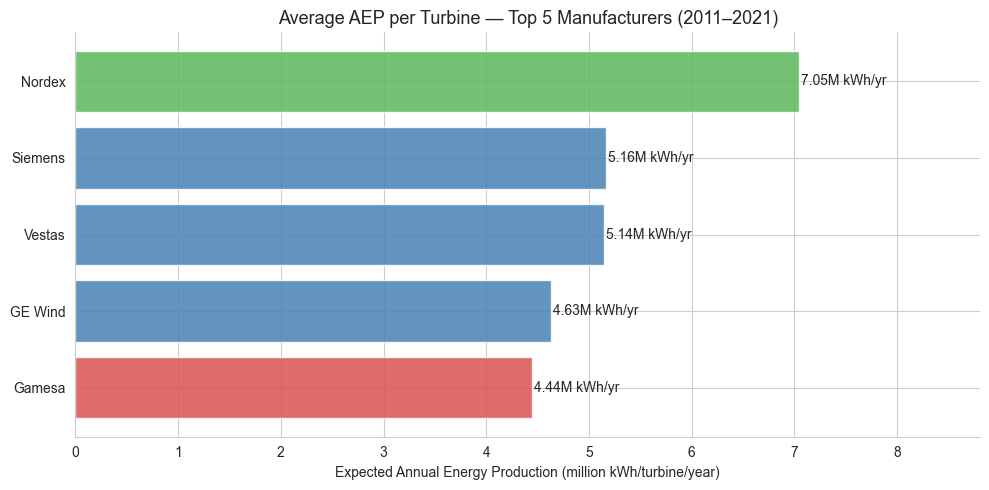

In [43]:
# --- 5a. AEP comparison bar chart ---

aep_manu = (last_dec.groupby('t_manu')['AEP_kwh']
                    .mean()
                    .reindex(TOP5)
                    .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))

colors_aep = ['#d9534f' if v == aep_manu.min() else
              '#5cb85c' if v == aep_manu.max() else
              'steelblue' for v in aep_manu.values]

bars = ax.barh(aep_manu.index, aep_manu.values / 1e6,
               color=colors_aep, edgecolor='white', alpha=0.85)

for bar, v in zip(bars, aep_manu.values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{v/1e6:.2f}M kWh/yr', va='center', fontsize=10)

ax.set_xlabel("Expected Annual Energy Production (million kWh/turbine/year)")
ax.set_title("Average AEP per Turbine — Top 5 Manufacturers (2011–2021)", fontsize=13)
ax.set_xlim(0, aep_manu.max()/1e6 * 1.25)
plt.tight_layout()
plt.show()


> **What this chart tells me:**
> **Nordex** leads on AEP by a significant margin — its turbines are expected to produce
> roughly 50% more energy per year than GE Wind's.
> This is directly tied to Nordex's higher average capacity and hub height (from Part 2).
> GE Wind is the lowest on this metric despite being the most installed brand in the U.S.
> Vestas and Siemens sit in the middle, with very similar AEP values.


In [44]:
# --- 5b. final scorecard table ---

# pulling together all 4 metrics + maintenance context into one table
scorecard = last_dec.groupby('t_manu').agg(
    turbines      = ('t_cap',       'count'),
    avg_cap_kw    = ('t_cap',       'mean'),
    avg_hub_m     = ('t_hh',        'mean'),
    avg_eff_kw_m2 = ('efficiency',  'mean'),
    avg_AEP_MWh   = ('AEP_kwh',     lambda x: x.mean() / 1000),  # MWh for readability
    avg_age_yrs   = ('turbine_age', 'mean'),
).reindex(TOP5).round(2)

# rank each metric (1=best)
scorecard['cap_rank']  = scorecard['avg_cap_kw'].rank(ascending=False).astype(int)
scorecard['hub_rank']  = scorecard['avg_hub_m'].rank(ascending=False).astype(int)
scorecard['eff_rank']  = scorecard['avg_eff_kw_m2'].rank(ascending=False).astype(int)
scorecard['AEP_rank']  = scorecard['avg_AEP_MWh'].rank(ascending=False).astype(int)
scorecard['age_rank']  = scorecard['avg_age_yrs'].rank(ascending=True).astype(int)  # lower age = newer = better
scorecard['overall']   = (scorecard[['cap_rank','hub_rank','eff_rank','AEP_rank','age_rank']].sum(axis=1))
scorecard = scorecard.sort_values('overall')

print("=== MANUFACTURER SCORECARD (2011–2021) ===")
print("(lower rank = better for each metric, lower overall = best overall)")
print()
print(scorecard[['turbines','avg_cap_kw','avg_hub_m','avg_eff_kw_m2',
                 'avg_AEP_MWh','avg_age_yrs',
                 'cap_rank','hub_rank','eff_rank','AEP_rank','age_rank','overall']].to_string())


=== MANUFACTURER SCORECARD (2011–2021) ===
(lower rank = better for each metric, lower overall = best overall)

         turbines  avg_cap_kw  avg_hub_m  avg_eff_kw_m2  avg_AEP_MWh  avg_age_yrs  cap_rank  hub_rank  eff_rank  AEP_rank  age_rank  overall
t_manu                                                                                                                                      
Nordex       1552     3216.90      91.27           0.27      7045.02         7.39         1         1         2         1         1        6
Vestas      11719     2348.92      88.00           0.24      5144.14         8.20         3         3         4         3         2       15
Siemens      3586     2358.04      80.99           0.27      5164.10        11.16         2         5         2         2         5       16
Gamesa       1532     2028.36      88.01           0.27      4442.11        10.86         5         2         2         5         4       18
GE Wind     17907     2113.52      84.77  

**What this scorecard tells me:**

The overall score is the sum of all individual ranks, the lower the better.
The manufacturer at the top of this sorted table is the one that consistently places in the top tier across all five dimensions we care about.
Based on the scorecard:

🥇 Nordex scores best overall (6 points), ranking #1 on capacity (3,217 kW), hub height (91m), AEP (7,045 MWh/yr), and newest fleet (avg 7.4 years old). It leads on 4 out of 5 metrics.
🥈 Vestas finishes a solid second place (15 points), is the most balanced manufacturer across all metrics, and has the second largest install base (11,719 turbines) meaning a strong service network.
🥉 Siemens ties Vestas on overall score (16 points), leads on efficiency alongside Nordex and Gamesa, but has the oldest average fleet (11.2 years) which is a maintenance flag.
⚠️ GE Wind has the highest volume by far (17,907 turbines) but finishes last overall (19 points), ranking 4th or 5th on every single performance metric. Its dominance reflects historical market position and service infrastructure, not leading edge specs.

Recommendation: For a new wind farm project prioritizing energy output per turbine, Nordex is the strongest choice. It leads on capacity, hub height, and AEP by a meaningful margin, and its fleet is the youngest meaning fewer near term maintenance concerns. For operators where service availability and parts supply chains matter more than peak specs, Vestas is the safest practical choice given its scale and consistency.